In [1]:
!pip install geopandas rasterio rtree shapely

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from shapely.geometry import box
from shapely.geometry import Point
from shapely.geometry import Polygon
from tqdm.auto import tqdm
import rasterio
from rasterio.mask import mask

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_DIR = '/content/drive/MyDrive/SmartSite/Step 2: Data Processing'
CAFE_PATH = os.path.join(BASE_DIR, 'Coffee_Tea_Data_GGMap.csv')
POI_PATH = os.path.join(BASE_DIR, 'Coffee_Tea_Data_POI.geojson')

print("⏳ Đang tải dữ liệu POI...")
poi_gdf = gpd.read_file(POI_PATH)

print("⏳ Đang tải dữ liệu Cafe & Khởi tạo hệ tọa độ...")
cafe_df = pd.read_csv(CAFE_PATH)
geometry = [Point(xy) for xy in zip(cafe_df['lng'], cafe_df['lat'])]

cafe_gdf = gpd.GeoDataFrame(cafe_df, geometry=geometry, crs="EPSG:4326")

print(f"📍 Tổng POI: {poi_gdf.shape[0]:,} điểm | Hệ tọa độ: {poi_gdf.crs}")
print(f"☕ Tổng Quán Cafe: {cafe_gdf.shape[0]:,} điểm | Hệ tọa độ: {cafe_gdf.crs}")

if poi_gdf.crs == cafe_gdf.crs:
    print("🎯 TUYỆT VỜI: Hệ tọa độ 2 file đã đồng bộ! Sẵn sàng giăng lưới.")
else:
    print("⚠️ CẢNH BÁO: Hệ tọa độ đang bị lệch, cần đồng bộ lại!")

cafe_gdf[['name', 'City', 'rating', 'reviews_count', 'sentiment_score_final', 'geometry']].head(10)

⏳ Đang tải dữ liệu POI...
⏳ Đang tải dữ liệu Cafe & Khởi tạo hệ tọa độ...
📍 Tổng POI: 51,727 điểm | Hệ tọa độ: EPSG:4326
☕ Tổng Quán Cafe: 8,647 điểm | Hệ tọa độ: EPSG:4326
🎯 TUYỆT VỜI: Hệ tọa độ 2 file đã đồng bộ! Sẵn sàng giăng lưới.


,name,City,rating,reviews_count,sentiment_score_final,geometry
0,Tiệm cafe Túi Thương Nhớ,DaNang,4.8,122,0.538,POINT (108.10785 16.0808)
1,Tiệm cà phê Trần,DaNang,4.7,7,0.781,POINT (108.14813 16.07457)
2,Tiệm Cà Phê Tháng Mười Hai,DaNang,4.7,36,0.802,POINT (108.14978 16.08335)
3,Tiệm Cà Phê Thời Thanh Xuân,DaNang,4.5,44,0.482,POINT (108.10959 16.03123)
4,THE POWERHOUSE 2 COFFEE & MORE,DaNang,4.6,359,0.681,POINT (108.14984 16.0713)
5,Home Land Coffee,DaNang,4.5,42,0.493,POINT (108.1075 16.09124)
6,Cafe Salavan,DaNang,4.1,132,0.738,POINT (108.14704 16.06895)
7,CaFe Mộc Gia,DaNang,4.5,38,0.540,POINT (108.14883 16.06594)
8,Quan Cafe Chocolate,DaNang,4.6,28,0.367,POINT (108.10207 16.06349)
9,Highlands Coffee,DaNang,4.2,380,0.452,POINT (108.14943 16.06849)


📊 Tham số hệ thống đã được chốt:
   ➤ C (Trung bình toàn hệ thống) = 4.62 sao
   ➤ m (Ngưỡng Median 50%)        = 23 đánh giá


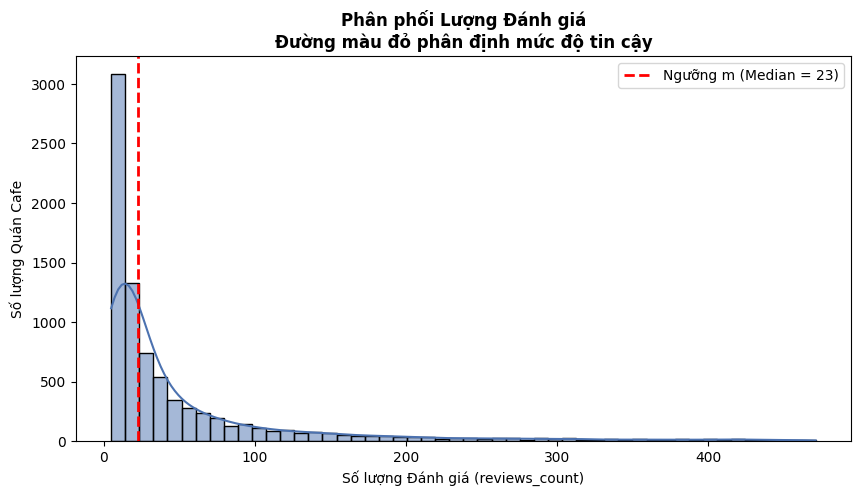

In [5]:
cafe_valid = cafe_gdf.dropna(subset=['rating', 'reviews_count']).copy()

# 1. Tính tham số C (Điểm trung bình của toàn bộ hệ thống)
C = cafe_valid['rating'].mean()

# 2. Tính tham số m (Ngưỡng review tối thiểu)
m = cafe_valid['reviews_count'].quantile(0.50)

print(f"📊 Tham số hệ thống đã được chốt:")
print(f"   ➤ C (Trung bình toàn hệ thống) = {C:.2f} sao")
print(f"   ➤ m (Ngưỡng Median 50%)        = {m:.0f} đánh giá")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(cafe_valid[cafe_valid['reviews_count'] <= cafe_valid['reviews_count'].quantile(0.95)]['reviews_count'],
             bins=50, kde=True, color='#4c72b0', ax=ax)

# Kẻ đường ranh giới m
ax.axvline(x=m, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng m (Median = {m:.0f})')
ax.set_title('Phân phối Lượng Đánh giá\nĐường màu đỏ phân định mức độ tin cậy', fontweight='bold')
ax.set_xlabel('Số lượng Đánh giá (reviews_count)')
ax.set_ylabel('Số lượng Quán Cafe')
ax.legend()
plt.show()

$$WR = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

Trong đó:
- $WR$: Weighted Rating (Điểm thực tế tụi mình cần).
- $v$: reviews_count (Số review của quán đó).
- $R$: rating (Điểm gốc của quán đó).
- $m$ và $C$: Đã tính ở Cell trên.

In [6]:
def bayesian_rating(x, m, C):
    v = x['reviews_count']
    R = x['rating']
    if pd.isna(v) or v == 0:
        return C
    return (v / (v + m) * R) + (m / (v + m) * C)

cafe_gdf['Weighted_Rating'] = cafe_gdf.apply(bayesian_rating, args=(m, C), axis=1)

cafe_gdf['Weighted_Rating'] = cafe_gdf['Weighted_Rating'].round(2)

# Lọc ra mấy quán 5.0 sao gốc, xếp theo lượt review từ thấp đến cao
fake_5_stars = cafe_gdf[cafe_gdf['rating'] == 5.0].sort_values('reviews_count').head(3)
real_5_stars = cafe_gdf[cafe_gdf['rating'] == 5.0].sort_values('reviews_count', ascending=False).head(3)

check_cols = ['name', 'reviews_count', 'rating', 'Weighted_Rating']

print("\nCÁC QUÁN 5.0 Sao nhưng ít review:")
display(fake_5_stars[check_cols])

print("\nCÁC QUÁN 5.0 Sao và nhiều review:")
display(real_5_stars[check_cols])


CÁC QUÁN 5.0 Sao nhưng ít review:


,name,reviews_count,rating,Weighted_Rating
4632,Cafe bối bối,5,5.0,4.68
4621,CÀ PHÊ ĐẠI LỘC TÂY NINH,5,5.0,4.68
4618,Tiệm Cà Phê Liên Quân,5,5.0,4.68



CÁC QUÁN 5.0 Sao và nhiều review:


,name,reviews_count,rating,Weighted_Rating
2134,Cafe Minh,1873,5.0,5.00
1980,1984 Coffee & Drinks,1723,5.0,4.99
21,Starbucks Ba Na Main Gate,1709,5.0,4.99


In [7]:
cafe_gdf['lng_check'] = cafe_gdf.geometry.x
cafe_gdf['lat_check'] = cafe_gdf.geometry.y

print("🚨 TỌA ĐỘ TRƯỚC KHI LỌC:")
bounds_before = cafe_gdf.groupby('City').agg(
    Min_Lng=('lng_check', 'min'),
    Max_Lng=('lng_check', 'max'),
    Min_Lat=('lat_check', 'min'),
    Max_Lat=('lat_check', 'max'),
    Tong_So_Quan=('name', 'count')
)
display(bounds_before)

condition = (cafe_gdf['lng_check'] >= 102) & (cafe_gdf['lng_check'] <= 110) & \
            (cafe_gdf['lat_check'] >= 8) & (cafe_gdf['lat_check'] <= 24)

cafe_gdf_clean = cafe_gdf[condition].copy()

dropped_count = len(cafe_gdf) - len(cafe_gdf_clean)
print(f"🗑️ Đã phát hiện và loại bỏ {dropped_count} quán cafe có tọa độ ảo văng ra khỏi Việt Nam!")


print("\n✨ TỌA ĐỘ SAU KHI LỌC:")
bounds_after = cafe_gdf_clean.groupby('City').agg(
    Min_Lng=('lng_check', 'min'),
    Max_Lng=('lng_check', 'max'),
    Min_Lat=('lat_check', 'min'),
    Max_Lat=('lat_check', 'max'),
    Tong_So_Quan=('name', 'count')
)
display(bounds_after)

cafe_gdf = cafe_gdf_clean.drop(columns=['lng_check', 'lat_check'])

🚨 TỌA ĐỘ TRƯỚC KHI LỌC:


,Min_Lng,Max_Lng,Min_Lat,Max_Lat,Tong_So_Quan
City,,,,,
DaNang,-77.011960,108.354183,15.874834,38.896465,881
HCM,106.291392,108.245112,10.311075,16.075785,4081
HaNoi,-121.184790,106.798494,1.305416,45.602012,3685


🗑️ Đã phát hiện và loại bỏ 142 quán cafe có tọa độ ảo văng ra khỏi Việt Nam!

✨ TỌA ĐỘ SAU KHI LỌC:


,Min_Lng,Max_Lng,Min_Lat,Max_Lat,Tong_So_Quan
City,,,,,
DaNang,107.988270,108.354183,15.874834,16.194079,880
HCM,106.291392,108.245112,10.311075,16.075785,4081
HaNoi,105.066423,106.798494,20.236352,21.453436,3544


**CHIA LƯỚI KHÔNG GIAN CÓ ĐÁNH INDEX (ROW, COL) ĐỂ LÀM MA TRẬN ẢNH**



In [8]:
grid_list = []
cell_size = 250

for city in tqdm(cafe_gdf['City'].unique(), desc="Đang xử lý các thành phố"):
    print(f"\n📍 Đang giăng lưới cho: {city}...")
    city_cafes = cafe_gdf[cafe_gdf['City'] == city]
    city_cafes_metric = city_cafes.to_crs(epsg=3857)

    x = city_cafes_metric.geometry.x
    y = city_cafes_metric.geometry.y

    xmin, xmax = x.quantile(0.01) - 2000, x.quantile(0.99) + 2000
    ymin, ymax = y.quantile(0.01) - 2000, y.quantile(0.99) + 2000

    cols = np.arange(xmin, xmax, cell_size)
    rows = np.arange(ymin, ymax, cell_size)

    grid_data = []
    for c_idx, c in enumerate(cols[:-1]):
        for r_idx, r in enumerate(rows[:-1]):
            grid_data.append({
                'geometry': box(c, r, c + cell_size, r + cell_size),
                'col_idx': c_idx,
                'row_idx': r_idx,
                'City': city
            })

    city_grid_gdf = gpd.GeoDataFrame(grid_data, crs="EPSG:3857")
    city_grid_gdf = city_grid_gdf.to_crs(epsg=4326)
    grid_list.append(city_grid_gdf)

master_grid = pd.concat(grid_list, ignore_index=True)
master_grid['Grid_ID'] = ['G_' + str(i).zfill(6) for i in range(len(master_grid))]

master_grid = master_grid[['Grid_ID', 'City', 'row_idx', 'col_idx', 'geometry']]

print(f"\nTổng số ô lưới (250x250m) tạo ra: {master_grid.shape[0]:,} ô")
display(master_grid.head(5))

Đang xử lý các thành phố:   0%|          | 0/3 [00:00<?, ?it/s]


📍 Đang giăng lưới cho: DaNang...

📍 Đang giăng lưới cho: HaNoi...

📍 Đang giăng lưới cho: HCM...

Tổng số ô lưới (250x250m) tạo ra: 279,970 ô


,Grid_ID,City,row_idx,col_idx,geometry
0,G_000000,DaNang,0,0,"POLYGON ((108.03886 15.86225, 108.03886 15.864..."
1,G_000001,DaNang,1,0,"POLYGON ((108.03886 15.86441, 108.03886 15.866..."
2,G_000002,DaNang,2,0,"POLYGON ((108.03886 15.86657, 108.03886 15.868..."
3,G_000003,DaNang,3,0,"POLYGON ((108.03886 15.86873, 108.03886 15.870..."
4,G_000004,DaNang,4,0,"POLYGON ((108.03886 15.87089, 108.03886 15.873..."


**Spatial Join**

In [9]:
# ==========================================
# 1. ĐẾM POI (KHÁCH HÀNG TIỀM NĂNG) CHO TỪNG Ô LƯỚI
# ==========================================

# Ghép POI vào Lưới
poi_in_grid = gpd.sjoin(poi_gdf, master_grid, how='inner', predicate='intersects')

poi_pivot = poi_in_grid.pivot_table(
    index='Grid_ID',
    columns='Category_Clean',
    values='name',
    aggfunc='count',
    fill_value=0
).reset_index()

poi_pivot.columns.name = None
poi_pivot.rename(columns={
    'Education': 'POI_Education',
    'Office': 'POI_Office',
    'Residential': 'POI_Residential',
    'Food': 'POI_Food',
    'Transport': 'POI_Transport',
    'Commercial': 'POI_Commercial',
    'Leisure': 'POI_Leisure',
    'Other': 'POI_Other'
}, inplace=True)

for col in ['POI_Food', 'POI_Transport', 'POI_Commercial', 'POI_Leisure']:
    if col not in poi_pivot.columns:
        poi_pivot[col] = 0

# ==========================================
# 2. ĐẾM CAFE (ĐỐI THỦ CẠNH TRANH) CHO TỪNG Ô LƯỚI
# ==========================================
cafe_in_grid = gpd.sjoin(cafe_gdf, master_grid, how='inner', predicate='intersects')

# Tính tổng số quán và điểm trung bình Rating/Sentiment của khu vực đó
cafe_stats = cafe_in_grid.groupby('Grid_ID').agg(
    Cafe_Count=('name', 'count'),
    Total_Reviews=('reviews_count', 'sum'),
    Avg_Rating=('rating', 'mean'),
    Avg_Weighted_Rating=('Weighted_Rating', 'mean'),
    Avg_Sentiment=('sentiment_score_final', 'mean')
).reset_index()

cafe_stats['Avg_Rating'] = cafe_stats['Avg_Rating'].round(3)
cafe_stats['Avg_Weighted_Rating'] = cafe_stats['Avg_Weighted_Rating'].round(3)
cafe_stats['Avg_Sentiment'] = cafe_stats['Avg_Sentiment'].round(3)

# ==========================================
# 3. TỔNG HỢP VÀO MASTER GRID
# ==========================================
# Gộp POI vào Lưới
grid_features = master_grid.merge(poi_pivot, on='Grid_ID', how='left')

# Gộp Cafe vào Lưới
grid_features = grid_features.merge(cafe_stats, on='Grid_ID', how='left')

# Điền số 0 cho những ô lưới không có POI hoặc không có Cafe
cols_to_fill = ['POI_Education', 'POI_Office', 'POI_Residential',
                'POI_Food', 'POI_Transport', 'POI_Commercial',
                'POI_Leisure', 'POI_Other', 'Cafe_Count']
grid_features[cols_to_fill] = grid_features[cols_to_fill].fillna(0).astype(int)

# Điền 0.0 cho Rating và Sentiment ở những nơi không có cafe
grid_features[['Avg_Rating', 'Avg_Sentiment']] = grid_features[['Avg_Rating', 'Avg_Sentiment']].fillna(0.0)

busy_grids = grid_features[(grid_features['Cafe_Count'] > 0) & (grid_features['POI_Office'] > 0)]
print(f"Tìm thấy {len(busy_grids):,} ô lưới cực kỳ sầm uất trên tổng số {len(grid_features):,} ô.")

# In thử 5 ô sầm uất nhất
display(busy_grids.sort_values(by='Cafe_Count', ascending=False).head(10))

Tìm thấy 457 ô lưới cực kỳ sầm uất trên tổng số 279,970 ô.


,Grid_ID,City,row_idx,col_idx,geometry,POI_Commercial,POI_Education,POI_Food,POI_Leisure,POI_Office,POI_Other,POI_Residential,POI_Transport,Cafe_Count,Total_Reviews,Avg_Rating,Avg_Weighted_Rating,Avg_Sentiment
154876,G_154876,HaNoi,322,309,"POLYGON ((105.94929 21.19811, 105.94929 21.200...",0,0,0,1,1,0,0,0,8,388.0,4.312,4.405,0.600
240694,G_240694,HCM,173,161,"POLYGON ((106.66469 10.71314, 106.66469 10.715...",0,0,0,2,2,0,5,0,5,173.0,4.660,4.610,0.627
156137,G_156137,HaNoi,281,312,"POLYGON ((105.95603 21.11224, 105.95603 21.114...",0,0,3,0,2,0,0,0,5,71.0,4.840,4.708,0.701
68917,G_068917,HaNoi,295,111,"POLYGON ((105.50463 21.14157, 105.50463 21.143...",0,1,5,0,2,0,0,0,4,270.0,4.250,4.322,0.712
120964,G_120964,HaNoi,262,231,"POLYGON ((105.77412 21.07243, 105.77412 21.074...",2,1,43,1,5,2,12,0,4,203.0,4.825,4.715,0.854
247978,G_247978,HCM,180,180,"POLYGON ((106.70736 10.72858, 106.70736 10.730...",1,0,6,0,17,0,1,1,4,705.0,4.650,4.582,0.667
101438,G_101438,HaNoi,266,186,"POLYGON ((105.67306 21.08081, 105.67306 21.082...",0,0,0,0,3,1,0,0,4,596.0,4.600,4.572,0.578
246466,G_246466,HCM,200,176,"POLYGON ((106.69837 10.77271, 106.69837 10.774...",6,0,34,0,2,1,0,2,4,5491.0,4.825,4.800,0.774
245315,G_245315,HCM,198,173,"POLYGON ((106.69164 10.7683, 106.69164 10.7705...",1,1,22,0,1,1,0,2,4,1053.0,4.750,4.732,0.561
155311,G_155311,HaNoi,323,310,"POLYGON ((105.95154 21.20021, 105.95154 21.202...",0,0,0,0,2,0,0,0,4,190.0,4.650,4.638,0.739


**Trích xuất Độ sáng Ban đêm (VIIRS NTL)**

In [10]:
# 1. KHAI BÁO TÊN FILE TƯƠNG ỨNG
TIFF_MAPPING = {
    'HaNoi': 'HaNoi_VIIRS.tif',
    'HCM': 'HCM_VIIRS.tif',
    'DaNang': 'DaNang_VIIRS.tif'
}

DIR = '/content/drive/MyDrive/SmartSite/Step 1: Extract/Results_CSV'

grid_features['NTL_Mean'] = 0.0

# 2. HÀM HÚT ĐỘ SÁNG (ZONAL STATISTICS)
def extract_nightlight(geom, raster_src):
    try:
        out_image, out_transform = mask(raster_src, [geom], crop=True)
        valid_pixels = out_image[(out_image > 0) & (out_image < 999)]
        if len(valid_pixels) > 0:
            return float(np.mean(valid_pixels))
        return 0.0
    except:
        return 0.0

# 3. CHẠY VÒNG LẶP ĐỂ XỬ LÝ TỪNG THÀNH PHỐ
for city, tiff_name in TIFF_MAPPING.items():
    print(f"\n📍 Đang xử lý vệ tinh cho khu vực: {city}...")
    tiff_path = os.path.join(DIR, tiff_name)

    # Kiểm tra xem file có tồn tại không
    if not os.path.exists(tiff_path):
        print(f"CẢNH BÁO: Không tìm thấy file {tiff_name} trong thư mục. Đã bỏ qua {city}!")
        continue

    try:
        with rasterio.open(tiff_path) as src:
            raster_crs = src.crs.to_string()

            # Lấy ra các ô lưới thuộc thành phố hiện tại
            city_grids = grid_features[grid_features['City'] == city].copy()

            # Ép hệ tọa độ lưới cho khớp với ảnh vệ tinh của thành phố đó
            if city_grids.crs.to_string() != raster_crs:
                city_grids = city_grids.to_crs(raster_crs)

            tqdm.pandas(desc=f"Hút NTL {city}")
            city_grids['NTL_Mean'] = city_grids['geometry'].progress_apply(lambda geom: extract_nightlight(geom, src))

            grid_features.loc[grid_features['City'] == city, 'NTL_Mean'] = city_grids['NTL_Mean'].values

            print(f"✅ Hoàn tất {city}!")

    except Exception as e:
        print(f"❌ Lỗi khi đọc file {tiff_name}: {e}")

# In thử Top 5 ô sáng nhất Việt Nam
display(grid_features.sort_values(by='NTL_Mean', ascending=False)[['Grid_ID', 'City', 'NTL_Mean', 'Cafe_Count', 'POI_Office']].head(5))


📍 Đang xử lý vệ tinh cho khu vực: HaNoi...


Hút NTL HaNoi:   0%|          | 0/158410 [00:00<?, ?it/s]

✅ Hoàn tất HaNoi!

📍 Đang xử lý vệ tinh cho khu vực: HCM...


Hút NTL HCM:   0%|          | 0/101112 [00:00<?, ?it/s]

✅ Hoàn tất HCM!

📍 Đang xử lý vệ tinh cho khu vực: DaNang...


Hút NTL DaNang:   0%|          | 0/20448 [00:00<?, ?it/s]

✅ Hoàn tất DaNang!


,Grid_ID,City,NTL_Mean,Cafe_Count,POI_Office
214516,G_214516,HCM,180.369995,0,0
203036,G_203036,HCM,177.364990,0,0
202270,G_202270,HCM,176.630005,0,0
202268,G_202268,HCM,168.404999,0,0
203034,G_203034,HCM,167.129990,0,0


In [11]:
# 1. TRÍCH XUẤT TỌA ĐỘ TÂM (CENTROID)
centroids = grid_features.to_crs(epsg=3857).geometry.centroid.to_crs(epsg=4326)

grid_features['Center_Lng'] = centroids.x
grid_features['Center_Lat'] = centroids.y

# 2. LỌC CỘT
final_cols = [
    'Grid_ID', 'City', 'Center_Lat', 'Center_Lng', 'row_idx', 'col_idx',
    'POI_Education', 'POI_Office', 'POI_Residential',
    'POI_Food', 'POI_Transport', 'POI_Commercial', 'POI_Leisure',
    'POI_Other',
    'Cafe_Count', 'Total_Reviews', 'Avg_Rating', 'Avg_Weighted_Rating', 'Avg_Sentiment', 'NTL_Mean'
]

df_ai_master = grid_features[final_cols].copy()

# 3. LỌC BỎ CÁC Ô LƯỚI "CHẾT"
df_ai_filtered = df_ai_master[
    (df_ai_master['Cafe_Count'] > 0) |
    (df_ai_master['POI_Education'] > 0) |
    (df_ai_master['POI_Office'] > 0) |
    (df_ai_master['POI_Residential'] > 0) |
    (df_ai_master['POI_Other'] > 0) |
    (df_ai_master['NTL_Mean'] > 0)
].copy()

print(f"📉 Số ô lưới ban đầu: {len(df_ai_master):,}")
print(f"📈 Số ô lưới CÓ SỰ SỐNG giữ lại để train AI: {len(df_ai_filtered):,}")
print(f"🗑️ Đã vứt bỏ {len(df_ai_master) - len(df_ai_filtered):,} ô lưới nằm ở rừng/biển.")

📉 Số ô lưới ban đầu: 279,970
📈 Số ô lưới CÓ SỰ SỐNG giữ lại để train AI: 73,974
🗑️ Đã vứt bỏ 205,996 ô lưới nằm ở rừng/biển.


**POI_Density** — tổng số POI (Education + Office + Residential + Khác) trong ô lưới đó. Đo mức độ đô thị hóa, khu vực càng nhiều công trình/tổ chức thì density càng cao → thường tốt cho F&B vì có nhiều người qua lại.

**POI_Entropy** — đo độ đa dạng loại POI trong ô lưới, dùng công thức Shannon Entropy:

$$H = -\sum_{c} \frac{N_c}{N} \log_{2} \frac{N_c}{N}$$
Trong đó:
- $N_c$ là số lượng mẫu thuộc lớp $c$.
- $N$ là tổng số mẫu.
- $\frac{N_c}{N}$ chính là xác suất $p$ của lớp đó.

In [12]:
from scipy.stats import entropy as scipy_entropy
from shapely.geometry import box
from tqdm import tqdm

# Lấy 2 ô liền nhau theo cột để tính step_lng
sample = grid_features.sort_values(['City', 'row_idx', 'col_idx'])
# Tìm 2 ô cùng row, col liền nhau
g = sample.groupby(['City', 'row_idx'])
for (city, row_i), grp in g:
    if len(grp) >= 2:
        grp_sorted = grp.sort_values('col_idx')
        lng_vals   = grp_sorted['Center_Lng'].values
        lat_vals   = grp_sorted['Center_Lat'].values
        step_lng   = abs(lng_vals[1] - lng_vals[0])
        if step_lng > 0:
            break

# Tính step_lat tương tự theo row
g2 = sample.groupby(['City', 'col_idx'])
for (city, col_i), grp in g2:
    if len(grp) >= 2:
        grp_sorted = grp.sort_values('row_idx')
        lat_vals2  = grp_sorted['Center_Lat'].values
        step_lat   = abs(lat_vals2[1] - lat_vals2[0])
        if step_lat > 0:
            break

HALF_LAT = step_lat / 2
HALF_LNG = step_lng / 2
print(f"step_lat={step_lat:.6f} | step_lng={step_lng:.6f}")
print(f"HALF_LAT={HALF_LAT:.6f} | HALF_LNG={HALF_LNG:.6f}")

# Tính Entropy và Density
categories   = ['Education', 'Office', 'Residential', 'Khác']
entropy_list = []
density_list = []

for _, row in tqdm(df_ai_filtered.iterrows(),
                   total=len(df_ai_filtered),
                   desc="Tính POI features"):
    bbox = box(
        row['Center_Lng'] - HALF_LNG,
        row['Center_Lat'] - HALF_LAT,
        row['Center_Lng'] + HALF_LNG,
        row['Center_Lat'] + HALF_LAT
    )
    poi_in_cell = poi_gdf[poi_gdf.geometry.within(bbox)]
    n_total     = len(poi_in_cell)
    density_list.append(n_total)

    if n_total == 0:
        entropy_list.append(0.0)
    else:
        counts = [(poi_in_cell['Category_Clean'] == cat).sum()
                  for cat in categories]
        counts = [c for c in counts if c > 0]
        probs  = np.array(counts) / n_total
        entropy_list.append(round(float(scipy_entropy(probs, base=2)), 4))

df_ai_filtered = df_ai_filtered.copy()
df_ai_filtered['POI_Density'] = density_list
df_ai_filtered['POI_Entropy']  = entropy_list

print("\nThống kê 2 features mới:")
print(f"  POI_Density — mean: {df_ai_filtered['POI_Density'].mean():.2f} | max: {df_ai_filtered['POI_Density'].max()}")
print(f"  POI_Entropy — mean: {df_ai_filtered['POI_Entropy'].mean():.4f} | max: {df_ai_filtered['POI_Entropy'].max():.4f}")
print(f"  Ô có Entropy > 0 : {(df_ai_filtered['POI_Entropy'] > 0).sum()}")
print(f"  Ô có Density > 0 : {(df_ai_filtered['POI_Density'] > 0).sum()}")

step_lat=0.002160 | step_lng=0.002246
HALF_LAT=0.001080 | HALF_LNG=0.001123


Tính POI features: 100%|██████████| 73974/73974 [10:14<00:00, 120.41it/s]



Thống kê 2 features mới:
  POI_Density — mean: 0.60 | max: 426
  POI_Entropy — mean: 0.0177 | max: 1.5850
  Ô có Entropy > 0 : 1384
  Ô có Density > 0 : 11345


**Xuất data**

In [13]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [14]:
grid_features = grid_features.drop(columns=['POI_Density', 'POI_Entropy'], errors='ignore')

grid_features = grid_features.merge(
    df_ai_filtered[['Grid_ID', 'POI_Density', 'POI_Entropy']],
    on='Grid_ID',
    how='left'
).fillna({'POI_Density': 0, 'POI_Entropy': 0.0})

print(f"grid_features sau merge: {grid_features.shape}")
print(f"Kiểm tra cột: {['POI_Density' in grid_features.columns, 'POI_Entropy' in grid_features.columns]}")

grid_features sau merge: (279970, 23)
Kiểm tra cột: [True, True]


In [15]:
for col in ['POI_Food', 'POI_Transport', 'POI_Commercial', 'POI_Leisure']:
    if col not in grid_features.columns:
        grid_features[col] = 0

K = 11
pad = K // 2

channels = ['POI_Education', 'POI_Office', 'POI_Residential',
            'POI_Food', 'POI_Transport', 'POI_Commercial',
            'POI_Leisure', 'POI_Other', 'NTL_Mean',
            'POI_Density', 'POI_Entropy']
num_channels = len(channels)
tensor_dict = {}

for city in grid_features['City'].unique():
    city_full     = grid_features[grid_features['City'] == city]
    city_filtered = df_ai_filtered[df_ai_filtered['City'] == city]

    max_row = city_full['row_idx'].max()
    max_col = city_full['col_idx'].max()

    # Xây nền — dùng vectorized thay iterrows cho nhanh
    city_matrix = np.zeros((max_row + 1, max_col + 1, num_channels))
    rows_idx = city_full['row_idx'].values.astype(int)
    cols_idx = city_full['col_idx'].values.astype(int)
    for ch_idx, ch in enumerate(channels):
        city_matrix[rows_idx, cols_idx, ch_idx] = city_full[ch].values

    padded_matrix = np.pad(city_matrix, pad_width=((pad, pad), (pad, pad), (0, 0)),
                           mode='constant', constant_values=0)

    for _, row in tqdm(city_filtered.iterrows(), total=len(city_filtered),
                       desc=f"Cắt không gian {city}"):
        grid_id = row['Grid_ID']
        r, c = int(row['row_idx']), int(row['col_idx'])
        tensor_dict[grid_id] = padded_matrix[r : r + K, c : c + K, :]

SAVE_DIR = '/content/drive/MyDrive/SmartSite/Step 3: Spatial_Grid/'
os.makedirs(SAVE_DIR, exist_ok=True)

df_ai_filtered.to_csv(os.path.join(SAVE_DIR, 'Spatial_Grid_Tabular.csv'), index=False, encoding='utf-8-sig')
np.savez_compressed(os.path.join(SAVE_DIR, 'Spatial_Tensors.npz'), **tensor_dict)

print(f"\n🎉 HOÀN TẤT STEP 3!")
print(f"➤ Đã lưu CSV: {len(df_ai_filtered):,} dòng.")
print(f"➤ Đã đóng gói {len(tensor_dict):,} khối Tensor 3D (Kích thước {K}x{K}x{num_channels}).")

Cắt không gian HCM: 100%|██████████| 27886/27886 [00:01<00:00, 18645.24it/s]



🎉 HOÀN TẤT STEP 3!
➤ Đã lưu CSV: 73,974 dòng.
➤ Đã đóng gói 73,974 khối Tensor 3D (Kích thước 11x11x11).
